In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"D:\mahmoud\depi\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
dtypes=df.dtypes
n_uniq=df.nunique()
pd.DataFrame({'dtypes':dtypes,'num uniq':n_uniq}).T

,age,sex,bmi,children,smoker,region,charges
dtypes,int64,object,float64,int64,object,object,float64
num uniq,47,2,548,6,2,4,1337


In [5]:
cols=['sex','smoker']
df[cols]=df[cols].astype('category')

In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [7]:
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,int64,category,object,float64
Num_Unique,47,2,548,6,2,4,1337


In [8]:
df.shape[0]

1338

In [9]:
null=df.isnull().sum()
ratio=(null/df.shape[0])*100
pd.DataFrame({'null':null,'ratio %':ratio})

,null,ratio %
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


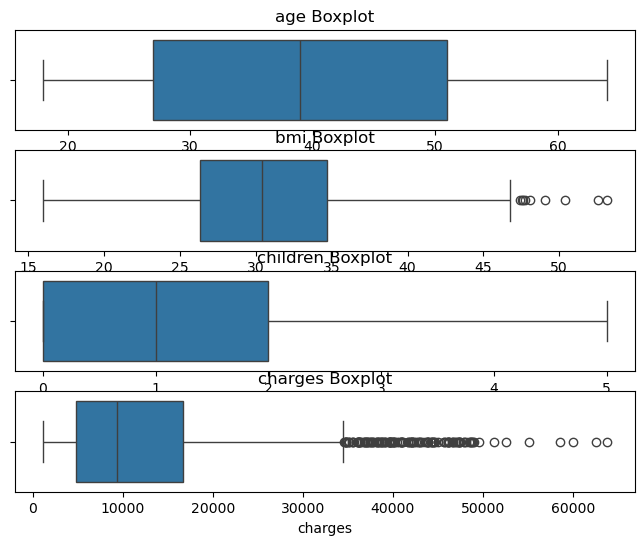

In [13]:
num_cols=df.select_dtypes('number').columns
n = len(num_cols)
plt.figure(figsize=(8,n*1.5))
for i , col in enumerate(num_cols):
    plt.subplot(n,1, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")


In [14]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_Fence = Q1 - 1.5*IQR
    upper_Fence = Q3 + 1.5*IQR
    lower_outliers=df[df[col]<lower_Fence][col].values
    upper_outlier=df[df[col]>upper_Fence][col].values
    df[col].replace(lower_outliers,lower_Fence,inplace=True)
    df[col].replace(upper_outlier,upper_Fence,inplace=True)

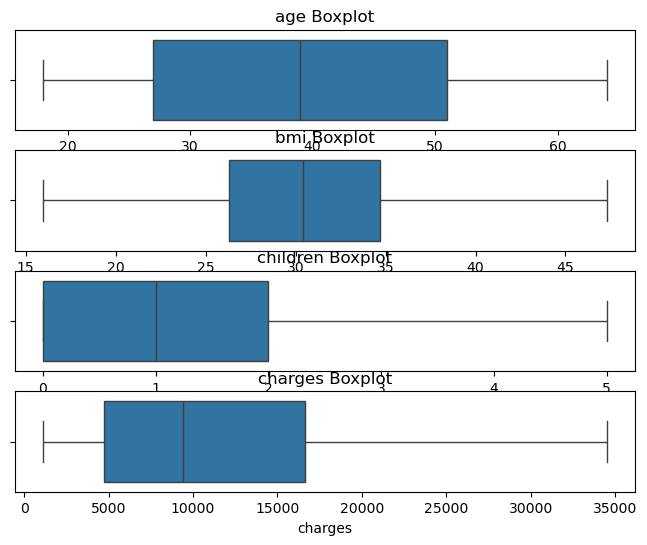

In [15]:
num_cols=df.select_dtypes('number').columns
n = len(num_cols)
plt.figure(figsize=(8,n*1.5))
for i , col in enumerate(num_cols):
    plt.subplot(n,1, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [16]:
df.duplicated().sum()

1

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

0

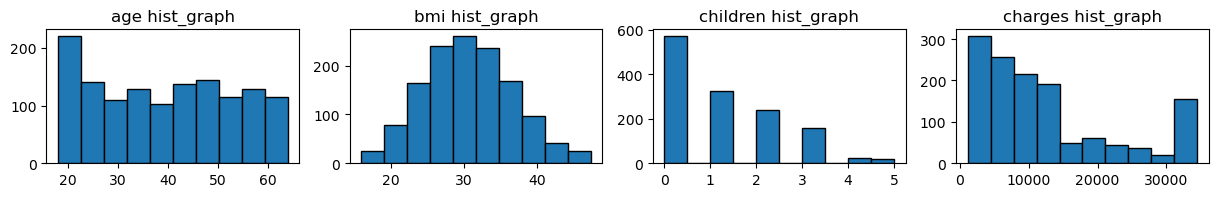

In [28]:
num_cols = df.select_dtypes('number').columns
n=len(num_cols)
plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols):
    plt.subplot(n, 4, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


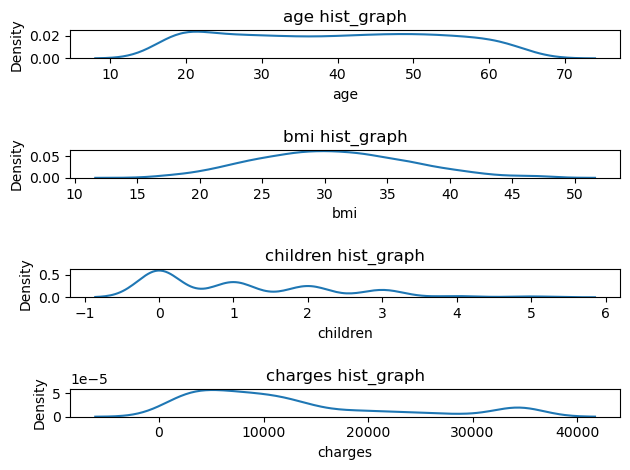

In [52]:
num_cols=df.select_dtypes('number').columns
n=len(num_cols)
plt.Figure(figsize=(15,n*3))
for i,col in enumerate(num_cols):
    plt.subplot(n, 1, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.tight_layout(h_pad=2)
plt.show()